## PREDICCIÓN DE RETORNOS — LSTM

Fase 7 — Un modelo LSTM por activo, usando ventanas de tiempo (secuencias) en vez de observaciones independientes como en SVR, para capturar dependencias temporales en los datos.

### Diferencia clave frente a SVR

SVR trata cada fila del dataset como independiente: mira el RSI, MACD, etc. de *un solo día* y predice el retorno futuro. LSTM en cambio recibe una **secuencia** de los últimos N días de esas mismas variables, y aprende patrones que dependen del orden temporal; por ejemplo, una tendencia que se viene formando a lo largo de varias sesiones, no solo el valor de hoy.

Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)


In [2]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "lstm"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_FILE = DATA_DIR / "features_dataset.csv"  # mismo dataset de horizonte 5 días que usó SVR, para comparar en igualdad de condiciones

TRAIN_TEST_SPLIT_DATE = "2024-01-01"
SEQUENCE_LENGTH = 20  # días de historia que ve el modelo para hacer cada predicción

FEATURE_COLS = [
    "return_1d", "return_5d", "return_10d", "return_21d", "return_63d",
    "sma_10", "sma_20", "sma_50",
    "ema_10", "ema_20", "ema_50",
    "vol_10", "vol_20", "vol_50",
    "rsi_14", "macd", "macd_signal",
    "bb_high", "bb_low"
]

TARGET_COL = "target_return_5d"
benchmark = "^GSPC"
MAX_WEIGHT = 0.15

print("Longitud de secuencia:", SEQUENCE_LENGTH, "días")
print("Directorio de resultados:", RESULTS_DIR)


Longitud de secuencia: 20 días
Directorio de resultados: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\lstm


## Carga del dataset (mismo de la Fase 4 / Fase 6, horizonte 5 días)

In [3]:
dataset = pd.read_csv(FEATURES_FILE, parse_dates=["Date"])
tickers = [t for t in sorted(dataset["ticker"].unique()) if t != benchmark]

print("Activos:", len(tickers))
dataset.head()


Activos: 20


,Date,ticker,return_5d,return_10d,return_21d,return_63d,return_1d,sma_10,sma_20,sma_50,...,ema_50,vol_10,vol_20,vol_50,rsi_14,macd,macd_signal,bb_high,bb_low,target_return_5d
0,2018-04-05,AAPL,0.037962,0.008933,-0.021905,0.007400,0.006934,39.600020,40.618843,40.054935,...,40.323861,0.350188,0.277843,0.295302,51.668555,-0.258639,-0.196717,43.021589,38.216096,0.007755
1,2018-04-06,AAPL,0.003577,-0.002783,-0.037993,-0.022906,-0.025578,39.588999,40.518473,40.030863,...,40.291025,0.368379,0.287977,0.298714,44.927547,-0.282602,-0.213894,42.934290,38.102656,0.037712
2,2018-04-09,AAPL,0.020219,0.030981,-0.038940,-0.024324,0.009918,39.708834,40.402041,40.029150,...,40.274834,0.347060,0.282557,0.296884,47.703722,-0.266916,-0.224499,42.702878,38.101203,0.033931
3,2018-04-10,AAPL,0.028862,0.002779,-0.037393,-0.002258,0.018818,39.720092,40.302726,40.040577,...,40.288706,0.264977,0.289640,0.299806,52.631237,-0.191721,-0.217943,42.372833,38.232619,0.028802
4,2018-04-11,AAPL,0.004837,0.024356,-0.051067,-0.006808,-0.004675,39.816242,40.214435,40.064789,...,40.294586,0.225191,0.288492,0.296126,51.313309,-0.145775,-0.203510,42.094472,38.334398,0.031315


## Función para construir secuencias

A diferencia de SVR (donde cada fila es una observación independiente), aquí cada muestra de entrenamiento es una **ventana de `SEQUENCE_LENGTH` días consecutivos** de todas las features, y la etiqueta es el target del último día de esa ventana.

In [4]:
def build_sequences(df: pd.DataFrame, feature_cols: list, target_col: str, seq_len: int):
    X_seq, y_seq, dates_seq = [], [], []

    features = df[feature_cols].values
    targets = df[target_col].values
    dates = df["Date"].values

    for i in range(seq_len, len(df)):
        X_seq.append(features[i - seq_len:i])
        y_seq.append(targets[i])
        dates_seq.append(dates[i])

    return np.array(X_seq), np.array(y_seq), np.array(dates_seq)


## Entrenamiento: un LSTM por activo

Mismo criterio que en SVR (Fase 6): escalado ajustado solo con datos de entrenamiento, split temporal (no aleatorio), y evaluación en el periodo de test. Se reserva un 15% del train como conjunto de **validación** (`validation_split=0.15`), y `EarlyStopping` vigila la pérdida de validación (`val_loss`), no la de entrenamiento — así el entrenamiento se detiene en el punto donde el modelo generaliza mejor, en vez de seguir ajustando hasta memorizar ruido del propio train. La arquitectura es intencionalmente simple (dos capas LSTM + dropout) para evitar sobreajuste dado el tamaño moderado de los datos por activo.

In [5]:
EPOCHS = 50
BATCH_SIZE = 32

results = []
predictions = {}
histories = {}

for ticker in tickers:

    df_t = dataset[dataset["ticker"] == ticker].sort_values("Date").reset_index(drop=True)

    if len(df_t) < SEQUENCE_LENGTH + 100:
        print(f"{ticker}: datos insuficientes, se omite")
        continue

    train_t = df_t[df_t["Date"] < TRAIN_TEST_SPLIT_DATE]
    test_t = df_t[df_t["Date"] >= TRAIN_TEST_SPLIT_DATE]

    scaler_X = StandardScaler()
    scaler_X.fit(train_t[FEATURE_COLS])

    scaler_y = StandardScaler()
    scaler_y.fit(train_t[[TARGET_COL]])

    df_t_scaled = df_t.copy()
    df_t_scaled[FEATURE_COLS] = scaler_X.transform(df_t[FEATURE_COLS])
    df_t_scaled[TARGET_COL] = scaler_y.transform(df_t[[TARGET_COL]])

    train_scaled = df_t_scaled[df_t_scaled["Date"] < TRAIN_TEST_SPLIT_DATE]
    combined_for_test = df_t_scaled[df_t_scaled["Date"] < test_t["Date"].min()].tail(SEQUENCE_LENGTH)
    test_scaled = pd.concat([combined_for_test, df_t_scaled[df_t_scaled["Date"] >= TRAIN_TEST_SPLIT_DATE]])

    X_train, y_train, _ = build_sequences(train_scaled, FEATURE_COLS, TARGET_COL, SEQUENCE_LENGTH)
    X_test, y_test_scaled, dates_test = build_sequences(test_scaled, FEATURE_COLS, TARGET_COL, SEQUENCE_LENGTH)

    model = Sequential([
        LSTM(32, return_sequences=True, input_shape=(SEQUENCE_LENGTH, len(FEATURE_COLS))),
        Dropout(0.2),
        LSTM(16),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.15,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred_scaled = model.predict(X_test, verbose=0).ravel()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_test = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    predictions[ticker] = pd.DataFrame({
        "Date": dates_test,
        "actual": y_test,
        "predicted": y_pred
    })
    histories[ticker] = {"loss": history.history["loss"], "val_loss": history.history["val_loss"]}

    results.append({
        "ticker": ticker,
        "epochs_entrenados": len(history.history["loss"]),
        "RMSE": rmse,
        "R2": r2
    })

    print(f"{ticker}: RMSE={rmse:.5f}  R2={r2:.4f}  (entrenado {len(history.history['loss'])} épocas)")

results_df = pd.DataFrame(results).set_index("ticker")


c:\Users\ofeli\anaconda3\envs\Finance\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


AAPL: RMSE=0.04212  R2=-0.0982  (entrenado 6 épocas)


c:\Users\ofeli\anaconda3\envs\Finance\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ADBE: RMSE=0.05152  R2=-0.0043  (entrenado 6 épocas)


c:\Users\ofeli\anaconda3\envs\Finance\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

V: RMSE=0.02846  R2=-0.0967  (entrenado 6 épocas)


c:\Users\ofeli\anaconda3\envs\Finance\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


WMT: RMSE=0.03593  R2=-0.1964  (entrenado 6 épocas)


c:\Users\ofeli\anaconda3\envs\Finance\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


XOM: RMSE=0.03411  R2=-0.0356  (entrenado 6 épocas)


## Tabla resumen de desempeño por activo

In [6]:
results_df.sort_values("R2", ascending=False).round(5)


,epochs_entrenados,RMSE,R2
ticker,,,
ADBE,6,0.05152,-0.00430
HD,6,0.03254,-0.01265
NVDA,6,0.06469,-0.02179
XOM,6,0.03411,-0.03564
PEP,6,0.02874,-0.04932
TSLA,7,0.08631,-0.06390
PG,9,0.02460,-0.06478
AMZN,6,0.04772,-0.08034
MSFT,6,0.04238,-0.09535


## Comparación directa: SVR vs. LSTM (mismo horizonte, 5 días)

Este es el resultado central de la Fase 7: ¿la arquitectura secuencial de LSTM captura señal que SVR no pudo?

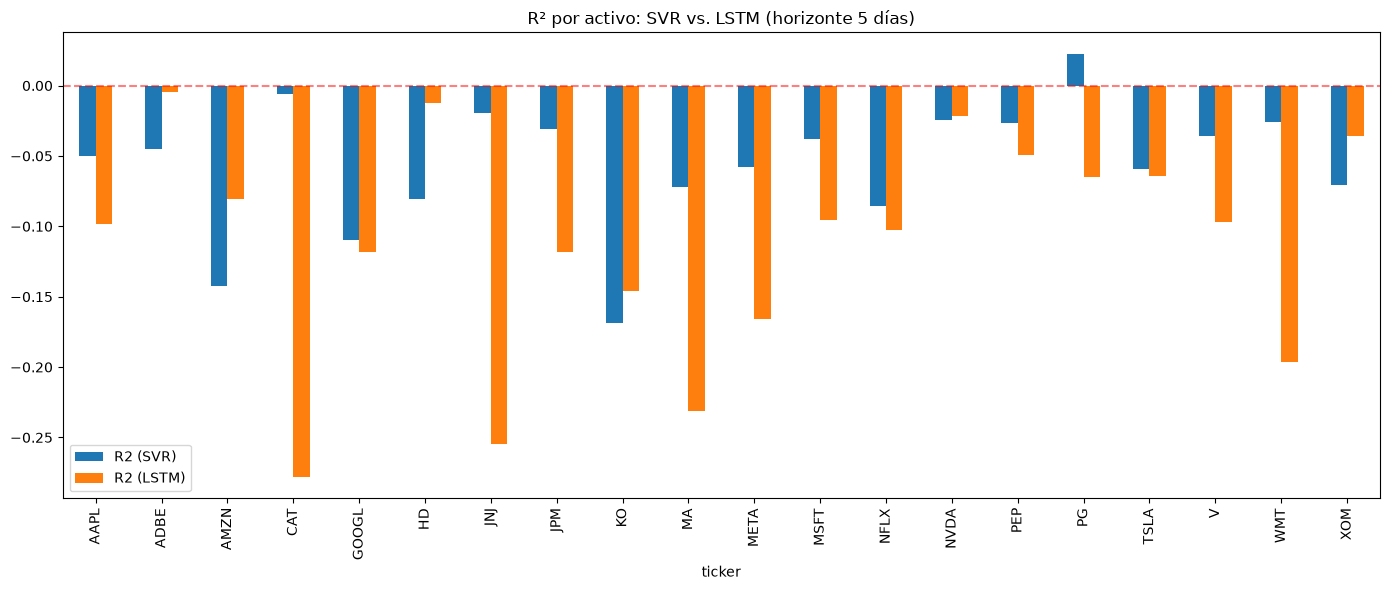

Promedio R2 SVR: -0.0563
Promedio R2 LSTM: -0.1117


In [7]:
RESULTS_SVR_FILE = PROJECT_ROOT / "results" / "svr" / "svr_performance_by_ticker.csv"

if RESULTS_SVR_FILE.exists():
    results_svr = pd.read_csv(RESULTS_SVR_FILE, index_col="ticker")

    r2_comparison = pd.DataFrame({
        "R2 (SVR)": results_svr["R2"],
        "R2 (LSTM)": results_df["R2"]
    }).dropna()

    r2_comparison.plot(kind="bar", figsize=(14, 6), title="R² por activo: SVR vs. LSTM (horizonte 5 días)")
    plt.axhline(0, color="red", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "01_r2_svr_vs_lstm.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Promedio R2 SVR:", r2_comparison['R2 (SVR)'].mean().round(4))
    print("Promedio R2 LSTM:", r2_comparison['R2 (LSTM)'].mean().round(4))
else:
    print("No se encontró", RESULTS_SVR_FILE, "— corre primero 05_svr.ipynb para poder comparar.")


## Curvas de pérdida — chequeo de sobreajuste

Ahora se grafican **entrenamiento y validación juntas**. Si la pérdida de validación deja de bajar (o empieza a subir) mientras la de entrenamiento sigue bajando, es la señal clásica de sobreajuste — y es justo lo que `EarlyStopping` sobre `val_loss` debería estar evitando ahora.

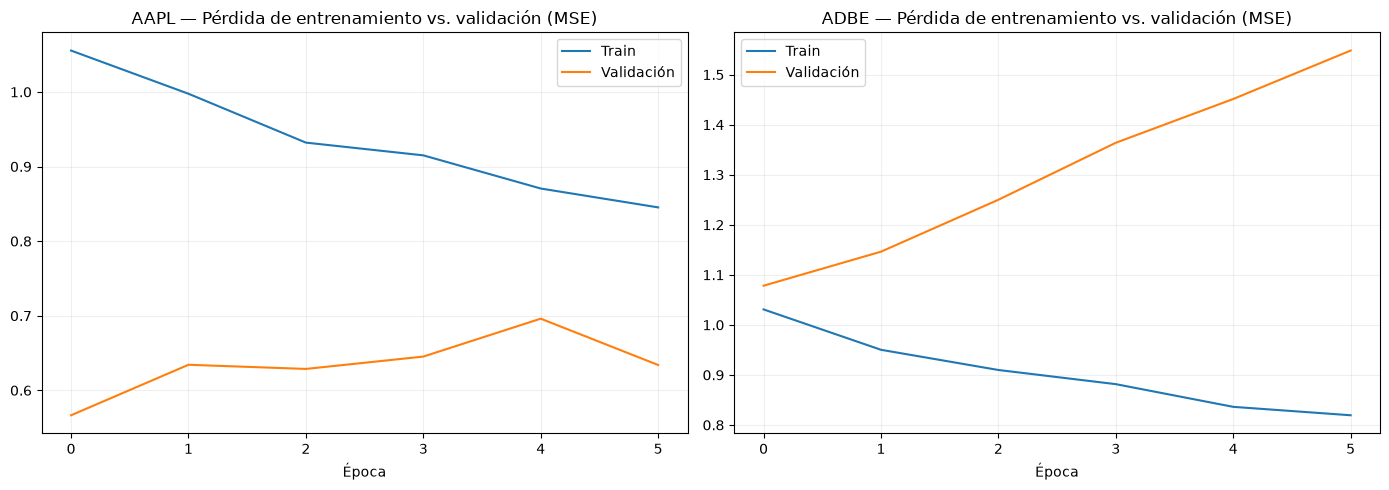

In [8]:
example_tickers = list(histories.keys())[:2]

fig, axes = plt.subplots(1, len(example_tickers), figsize=(14, 5))

for ax, ticker in zip(axes, example_tickers):
    ax.plot(histories[ticker]["loss"], label="Train")
    ax.plot(histories[ticker]["val_loss"], label="Validación")
    ax.set_title(f"{ticker} — Pérdida de entrenamiento vs. validación (MSE)")
    ax.set_xlabel("Época")
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_curvas_perdida.png", dpi=300, bbox_inches="tight")
plt.show()


## Predicho vs. real — ejemplo visual (2 mejores activos)

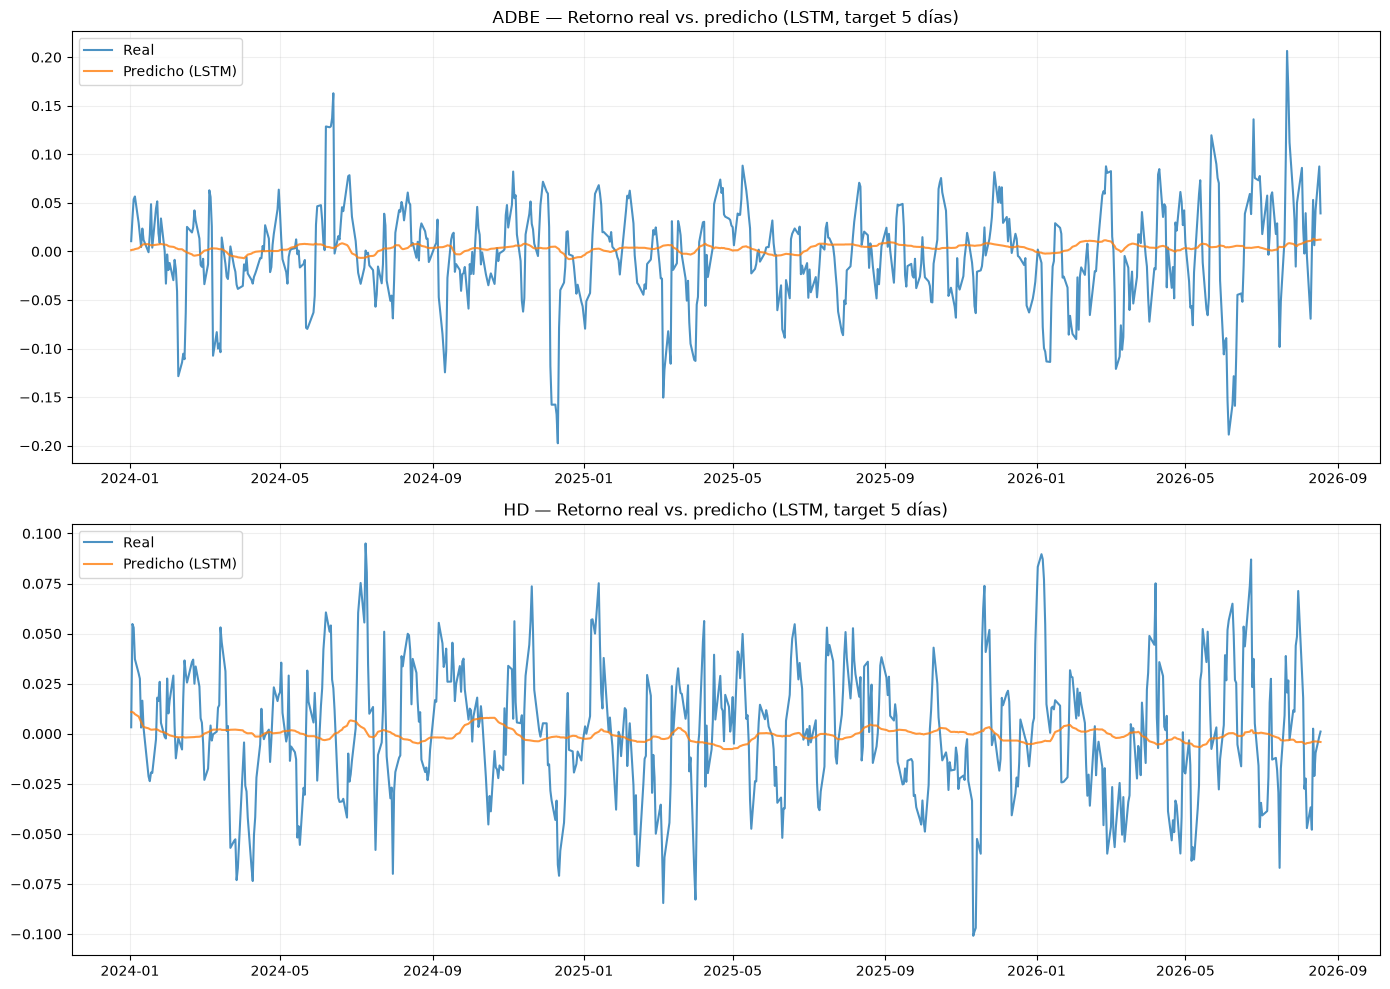

In [9]:
example_tickers_best = results_df.sort_values("R2", ascending=False).index[:2].tolist()

fig, axes = plt.subplots(len(example_tickers_best), 1, figsize=(14, 5 * len(example_tickers_best)))
if len(example_tickers_best) == 1:
    axes = [axes]

for ax, ticker in zip(axes, example_tickers_best):
    pred_df = predictions[ticker]
    ax.plot(pred_df["Date"], pred_df["actual"], label="Real", alpha=0.8)
    ax.plot(pred_df["Date"], pred_df["predicted"], label="Predicho (LSTM)", alpha=0.8)
    ax.set_title(f"{ticker} — Retorno real vs. predicho (LSTM, target 5 días)")
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_predicho_vs_real.png", dpi=300, bbox_inches="tight")
plt.show()


## Vector de retornos esperados (mu_lstm)

Misma lógica de capitalización compuesta usada para `mu_svr`, para poder comparar de forma justa.

In [10]:
PERIODS_PER_YEAR = 252 / 5

mu_lstm = {}
for ticker, pred_df in predictions.items():
    mean_5d_return = pred_df["predicted"].mean()
    mu_lstm[ticker] = (1 + mean_5d_return) ** PERIODS_PER_YEAR - 1

mu_lstm = pd.Series(mu_lstm, name="mu_lstm").sort_values(ascending=False)

mu_lstm


XOM      0.379099
PEP      0.306973
NVDA     0.226293
ADBE     0.188277
HD      -0.029486
JNJ     -0.074054
KO      -0.138454
V       -0.159114
GOOGL   -0.219907
NFLX    -0.225071
JPM     -0.234236
AMZN    -0.284349
AAPL    -0.284414
PG      -0.302507
WMT     -0.331693
MSFT    -0.333032
MA      -0.409364
CAT     -0.459620
TSLA    -0.573040
META    -0.623462
Name: mu_lstm, dtype: float32

## Markowitz con mu_lstm (mismo procedimiento que con mu_svr)

In [12]:
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier

prices_for_mu = pd.read_csv(DATA_DIR / "adjusted_prices.csv", index_col=0, parse_dates=True)
asset_prices_lstm = prices_for_mu.drop(columns=[benchmark])

S_shrink_lstm = CovarianceShrinkage(asset_prices_lstm).ledoit_wolf()

ef_lstm = EfficientFrontier(mu_lstm, S_shrink_lstm, weight_bounds=(0, MAX_WEIGHT))

# Cota mínima: si un activo entra al portafolio, debe tener al menos 1% de peso
ef_lstm.add_constraint(lambda w: w >= 0.01)
raw_weights_lstm = ef_lstm.max_sharpe(risk_free_rate=0.02)
weights_lstm = ef_lstm.clean_weights()

perf_lstm = ef_lstm.portfolio_performance(verbose=True, risk_free_rate=0.02)

pd.Series(weights_lstm).sort_values(ascending=False)


Expected annual return: 10.7%
Annual volatility: 23.0%
Sharpe Ratio: 0.38


XOM      0.15
PEP      0.15
NVDA     0.15
ADBE     0.15
HD       0.15
JNJ      0.11
KO       0.01
V        0.01
GOOGL    0.01
NFLX     0.01
JPM      0.01
AMZN     0.01
AAPL     0.01
PG       0.01
WMT      0.01
MSFT     0.01
MA       0.01
CAT      0.01
TSLA     0.01
META     0.01
dtype: float64

## Backtest: Markowitz + LSTM vs. las demás estrategias

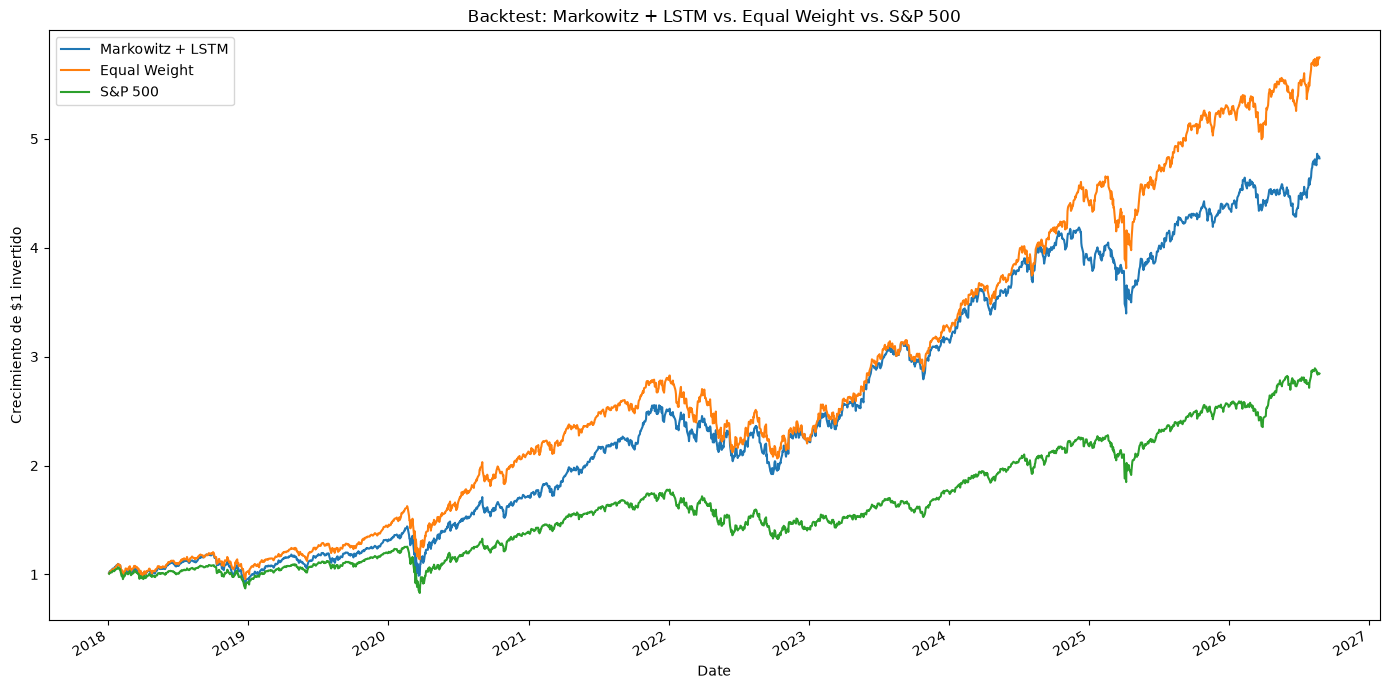

In [13]:
returns_for_backtest = pd.read_csv(DATA_DIR / "daily_returns.csv", index_col=0, parse_dates=True)
returns_for_backtest.index.name = "Date"
returns_for_backtest_clean = returns_for_backtest.dropna(how="all")
asset_returns_lstm = returns_for_backtest_clean.drop(columns=[benchmark])

def portfolio_cumulative_return(weights: pd.Series, returns: pd.DataFrame) -> pd.Series:
    aligned_weights = weights.reindex(returns.columns).fillna(0)
    portfolio_returns = (returns * aligned_weights).sum(axis=1)
    return (1 + portfolio_returns).cumprod()

n_assets = len(asset_returns_lstm.columns)
weights_equal_lstm = pd.Series(1 / n_assets, index=asset_returns_lstm.columns)

comparison_lstm = pd.DataFrame({
    "Markowitz + LSTM": portfolio_cumulative_return(pd.Series(weights_lstm), asset_returns_lstm),
    "Equal Weight": portfolio_cumulative_return(weights_equal_lstm, asset_returns_lstm),
    "S&P 500": (1 + returns_for_backtest_clean[benchmark]).cumprod()
})

comparison_lstm.plot(figsize=(14, 7), title="Backtest: Markowitz + LSTM vs. Equal Weight vs. S&P 500")
plt.ylabel("Crecimiento de $1 invertido")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "04_backtest_markowitz_lstm.png", dpi=300, bbox_inches="tight")
plt.show()


## Tabla resumen de métricas

Recuerda completar manualmente las filas de Markowitz clásico (26.7% / 20.0% / 1.24 / -28.1%) y Markowitz+SVR (25.4% / 24.7% / 0.94 / -35.8%) para tener la comparación completa de las cinco estrategias en tu informe.

In [15]:
def annualized_metrics(cum_returns: pd.Series, risk_free_rate: float = 0.02) -> dict:
    daily_returns = cum_returns.pct_change().dropna()
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    max_drawdown = (cum_returns / cum_returns.cummax() - 1).min()
    return {
        "Retorno anualizado": ann_return,
        "Volatilidad anualizada": ann_vol,
        "Sharpe Ratio": sharpe,
        "Máximo Drawdown": max_drawdown
    }

summary_lstm = pd.DataFrame({
    col: annualized_metrics(comparison_lstm[col]) for col in comparison_lstm.columns
}).T

summary_lstm.round(4)


,Retorno anualizado,Volatilidad anualizada,Sharpe Ratio,Máximo Drawdown
Markowitz + LSTM,0.2018,0.2058,0.8835,-0.3144
Equal Weight,0.2224,0.2025,0.9997,-0.2998
S&P 500,0.1392,0.1922,0.6201,-0.3392


## Guardar resultados

In [16]:
results_df.to_csv(RESULTS_DIR / "lstm_performance_by_ticker.csv")
mu_lstm.to_csv(RESULTS_DIR / "mu_lstm.csv")
pd.Series(weights_lstm).to_csv(RESULTS_DIR / "weights_markowitz_lstm.csv")
comparison_lstm.to_csv(RESULTS_DIR / "backtest_markowitz_lstm.csv")
summary_lstm.to_csv(RESULTS_DIR / "summary_markowitz_lstm.csv")

print("Resultados guardados en:", RESULTS_DIR)


Resultados guardados en: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\lstm
